In [1]:
import os
import glob
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Blast import NCBIWWW, NCBIXML
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up directory structure
base_dir = "bompar_project"
os.makedirs(f"{base_dir}/raw_data", exist_ok=True)
os.makedirs(f"{base_dir}/trimmed_sequences", exist_ok=True)
os.makedirs(f"{base_dir}/aligned_sequences", exist_ok=True)
os.makedirs(f"{base_dir}/blast_results", exist_ok=True)
os.makedirs(f"{base_dir}/figures", exist_ok=True)
os.makedirs(f"{base_dir}/genbank_submission", exist_ok=True)

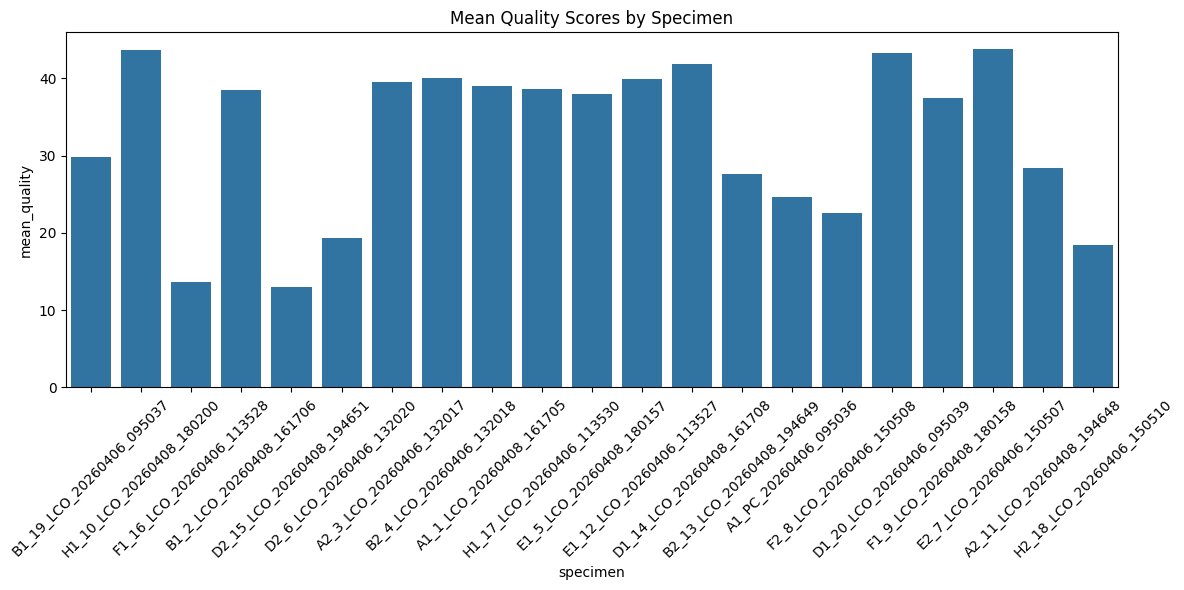

In [2]:
def read_ab1_files(file_paths):
    """Read AB1 files and extract sequence data with quality scores"""
    sequences = {}
    quality_reports = []
    
    for file_path in file_paths:
        try:
            # Read AB1 file using Bio.SeqIO
            record = SeqIO.read(file_path, "abi")
            specimen_id = os.path.basename(file_path).replace('.ab1', '')
            
            # Extract sequence and quality scores
            sequence = str(record.seq)
            quality = record.letter_annotations["phred_quality"]
            
            sequences[specimen_id] = {
                'record': record,
                'sequence': sequence,
                'quality': quality,
                'file_path': file_path
            }
            
            # Generate quality report
            quality_reports.append({
                'specimen': specimen_id,
                'length': len(sequence),
                'mean_quality': np.mean(quality),
                'min_quality': np.min(quality),
                'max_quality': np.max(quality)
            })
            
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
    
    return sequences, pd.DataFrame(quality_reports)

# Get all AB1 files
ab1_files = glob.glob("bompar_project/raw_data/*.ab1")  # Update path 
sequences_dict, quality_df = read_ab1_files(ab1_files)

# Visualize quality
plt.figure(figsize=(12, 6))
sns.barplot(data=quality_df, x='specimen', y='mean_quality')
plt.xticks(rotation=45)
plt.title('Mean Quality Scores by Specimen')
plt.tight_layout()
plt.savefig(f"{base_dir}/figures/quality_scores.png", dpi=300)
plt.show()

In [3]:
from Bio import Entrez
Entrez.email = "hommurat9001@gmail.com"  # Always set your email

def trim_sequence(record, quality_threshold=20, window_size=30):
    """Trim low quality ends using sliding window"""
    quality = record.letter_annotations["phred_quality"]
    
    # Find start position
    start_idx = 0
    for i in range(len(quality) - window_size):
        if np.mean(quality[i:i+window_size]) >= quality_threshold:
            start_idx = i
            break
    
    # Find end position  
    end_idx = len(quality)
    for i in range(len(quality) - window_size, 0, -1):
        if np.mean(quality[i:i+window_size]) >= quality_threshold:
            end_idx = i + window_size
            break
    
    return record[start_idx:end_idx]

# Trim all sequences
trimmed_sequences = {}
for specimen_id, data in sequences_dict.items():
    trimmed = trim_sequence(data['record'])
    trimmed_sequences[specimen_id] = trimmed
    
    # Save trimmed sequence
    SeqIO.write(trimmed, 
                f"{base_dir}/trimmed_sequences/{specimen_id}_trimmed.fasta", 
                "fasta")

In [4]:
def verify_co1_region(sequence):
    """Check if sequence likely contains CO1 region"""
    # Common CO1 conserved motifs in insects
    co1_motifs = ['GGD', 'GGA', 'WYF', 'PIF']  # Amino acid motifs
    translated = sequence.seq.translate()
    
    motifs_found = []
    for motif in co1_motifs:
        if motif in str(translated):
            motifs_found.append(motif)
    
    return motifs_found, len(motifs_found) > 2

co1_verification = {}
for specimen_id, record in trimmed_sequences.items():
    motifs, is_co1 = verify_co1_region(record)
    co1_verification[specimen_id] = {
        'motifs_found': motifs,
        'is_likely_co1': is_co1
    }

/home/hommurat/sanger_data_analysis_pipeline/.venv/lib/python3.12/site-packages/Bio/Seq.py:2877: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [5]:
def blast_novel_sequences(sequence_record, specimen_id):
    """BLAST sequence against nr database"""
    try:
        result_handle = NCBIWWW.qblast(
            "blastn", 
            "nt", 
            sequence_record.seq,
            megablast=True,
            hitlist_size=10
        )
        
        blast_records = NCBIXML.parse(result_handle)
        blast_results = []
        
        for blast_record in blast_records:
            for alignment in blast_record.alignments[:5]:
                for hsp in alignment.hsps[:1]:
                    blast_results.append({
                        'specimen': specimen_id,
                        'hit_id': alignment.hit_id,
                        'hit_def': alignment.hit_def,
                        'e_value': hsp.expect,
                        'score': hsp.score,
                        'identity': hsp.identities / hsp.align_length * 100,
                        'alignment_length': hsp.align_length
                    })
        
        return pd.DataFrame(blast_results)
    
    except Exception as e:
        print(f"BLAST failed for {specimen_id}: {e}")
        return pd.DataFrame()

# Perform BLAST (consider doing this incrementally or offline)
blast_all_results = []
for specimen_id, record in list(trimmed_sequences.items()):  # Start with 5
    results = blast_novel_sequences(record, specimen_id)
    if not results.empty:
        blast_all_results.append(results)
        results.to_csv(f"{base_dir}/blast_results/{specimen_id}_blast.csv")

if blast_all_results:
    blast_df = pd.concat(blast_all_results)
    blast_df.to_csv(f"{base_dir}/blast_results/all_blast_results.csv")

In [8]:
from Bio.Align.Applications import MafftCommandline

def align_sequences(sequence_dict, reference=None):
    """Align sequences using MAFFT"""
    
    # Write all sequences to temp file
    temp_input = f"{base_dir}/aligned_sequences/temp_input.fasta"
    temp_output = f"{base_dir}/aligned_sequences/aligned.fasta"
    
    sequences = list(sequence_dict.values())
    SeqIO.write(sequences, temp_input, "fasta")
    
    # Run MAFFT
    mafft_cline = MafftCommandline(
        input=temp_input,
        auto=True,
        maxiterate=1000,
        localpair=True
    )
    
    stdout, stderr = mafft_cline()
    
    with open(temp_output, 'w') as handle:
        handle.write(stdout)
    
    # Read alignment
    alignment = list(SeqIO.parse(temp_output, "fasta"))
    return alignment

# Align your sequences
aligned_seqs = align_sequences(trimmed_sequences)

ModuleNotFoundError: No module named 'Bio.Align.Applications'

In [ ]:
from Bio import AlignIO
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
from Bio import Phylo

def create_phylogenetic_tree(alignment_file):
    """Create a neighbor-joining tree"""
    alignment = AlignIO.read(alignment_file, "fasta")
    
    # Calculate distance matrix
    calculator = DistanceCalculator('identity')
    distance_matrix = calculator.get_distance(alignment)
    
    # Build tree
    constructor = DistanceTreeConstructor()
    tree = constructor.nj(distance_matrix)
    
    # Root at midpoint
    tree.root_at_midpoint()
    
    # Draw tree
    fig, ax = plt.subplots(figsize=(12, 8))
    Phylo.draw(tree, axes=ax, do_show=False)
    plt.title("CO1 Gene Tree - Armenian Bumblebees")
    plt.tight_layout()
    plt.savefig(f"{base_dir}/figures/phylogenetic_tree.png", dpi=300)
    plt.show()
    
    return tree

# Create phylogenetic tree
tree = create_phylogenetic_tree(f"{base_dir}/aligned_sequences/aligned.fasta")

In [ ]:
def create_genbank_submission(sequence_records, morphological_ids):
    """Create GenBank submission files with morphological IDs"""
    
    submission_records = []
    
    for specimen_id, record in sequence_records.items():
        # Create new SeqRecord with metadata
        new_record = SeqRecord(
            record.seq,
            id=f"{specimen_id}_CO1",
            name=specimen_id,
            description=f"Bombus sp. {morphological_ids.get(specimen_id, 'unknown')} COI gene, partial cds"
        )
        
        # Add features
        new_record.annotations = {
            'organism': 'Bombus sp.',
            'mol_type': 'genomic DNA',
            'country': 'Armenia',
            'collection_date': '2023',  # Update as needed
            'isolate': specimen_id,
            'gene': 'COI',
            'product': 'cytochrome c oxidase subunit I'
        }
        
        # Add morphology ID as note
        new_record.annotations['note'] = f"Morphologically identified as: {morphological_ids.get(specimen_id, 'unknown')}"
        
        submission_records.append(new_record)
    
    # Save in GenBank format
    SeqIO.write(submission_records, 
                f"{base_dir}/genbank_submission/bumblebee_co1.gb", 
                "genbank")
    
    # Also save as FASTA for easy sharing
    SeqIO.write(submission_records, 
                f"{base_dir}/genbank_submission/bumblebee_co1.fasta", 
                "fasta")
    
    return submission_records

# Example morphological IDs
morphological_ids = {
    'BBA001': 'Bombus terrestris',
    'BBA002': 'Bombus lucorum',
    'BBA003': 'Bombus lapidarius',
    # Add all your specimens
}

# Create submission files
gb_records = create_genbank_submission(trimmed_sequences, morphological_ids)

In [ ]:
def generate_report(quality_df, co1_verification, blast_df=None):
    """Generate comprehensive analysis report"""
    
    report = []
    report.append("# Bumblebee CO1 Sequencing Analysis Report")
    report.append("## Armenian Bombus Species - Novel Sequences")
    report.append(f"\nAnalysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}")
    
    # Summary statistics
    report.append("\n## Summary Statistics")
    report.append(f"- Total specimens sequenced: {len(quality_df)}")
    report.append(f"- Mean sequence length: {quality_df['length'].mean():.0f} bp")
    report.append(f"- Mean quality score: {quality_df['mean_quality'].mean():.1f}")
    
    # CO1 verification
    co1_confirmed = sum(1 for v in co1_verification.values() if v['is_likely_co1'])
    report.append(f"\n## CO1 Region Verification")
    report.append(f"- Sequences confirmed as CO1: {co1_confirmed}/{len(co1_verification)}")
    
    # Save report
    with open(f"{base_dir}/analysis_report.md", 'w') as f:
        f.write('\n'.join(report))
    
    return '\n'.join(report)

report = generate_report(quality_df, co1_verification)
print(report)